<a href="https://colab.research.google.com/github/xr-cc/DSCoV-Workshop-on-Topic-Modeling/blob/main/topic_modeling_MutSig_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install packages

In [7]:
# for an example dataset of DNA mutation counts
install.packages("mutSignatures")

# for performing NMF (mutational signature analysis)
install.packages('NMF')

# for visualization
install.packages("pheatmap")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Load packages

In [8]:
library(NMF)
library(mutSignatures)
library(pheatmap)

# Load data
There are $M$ samples, $N$ SBS96 types (mutation types classified based on six substitution subtypes: C>A, C>G, C>T, T>A, T>C, and T>G, and the nucleotides immediately 5' and 3' to the mutation).

We have $X$, the $M\times N$ mutation-count matrix.

In [44]:
data("mutSigData")   # loads multiple demo objects

# see what's in the data
names(mutSigData)

# take the 96×50 mutation-count matrix (rows = SBS96 types, cols = samples)
X <- mutSigData$blcaMUTS
X <- t(X)
dim(X)   # M=50, N=96

[1] "inputA"     "inputB"     "inputC"     "inputC.ctx" "inputD"    
[6] "blcaMUTS"   "blcaSIGS"   ".addON"     "inputS"

[1] 50 96

## Visualize (log) count data

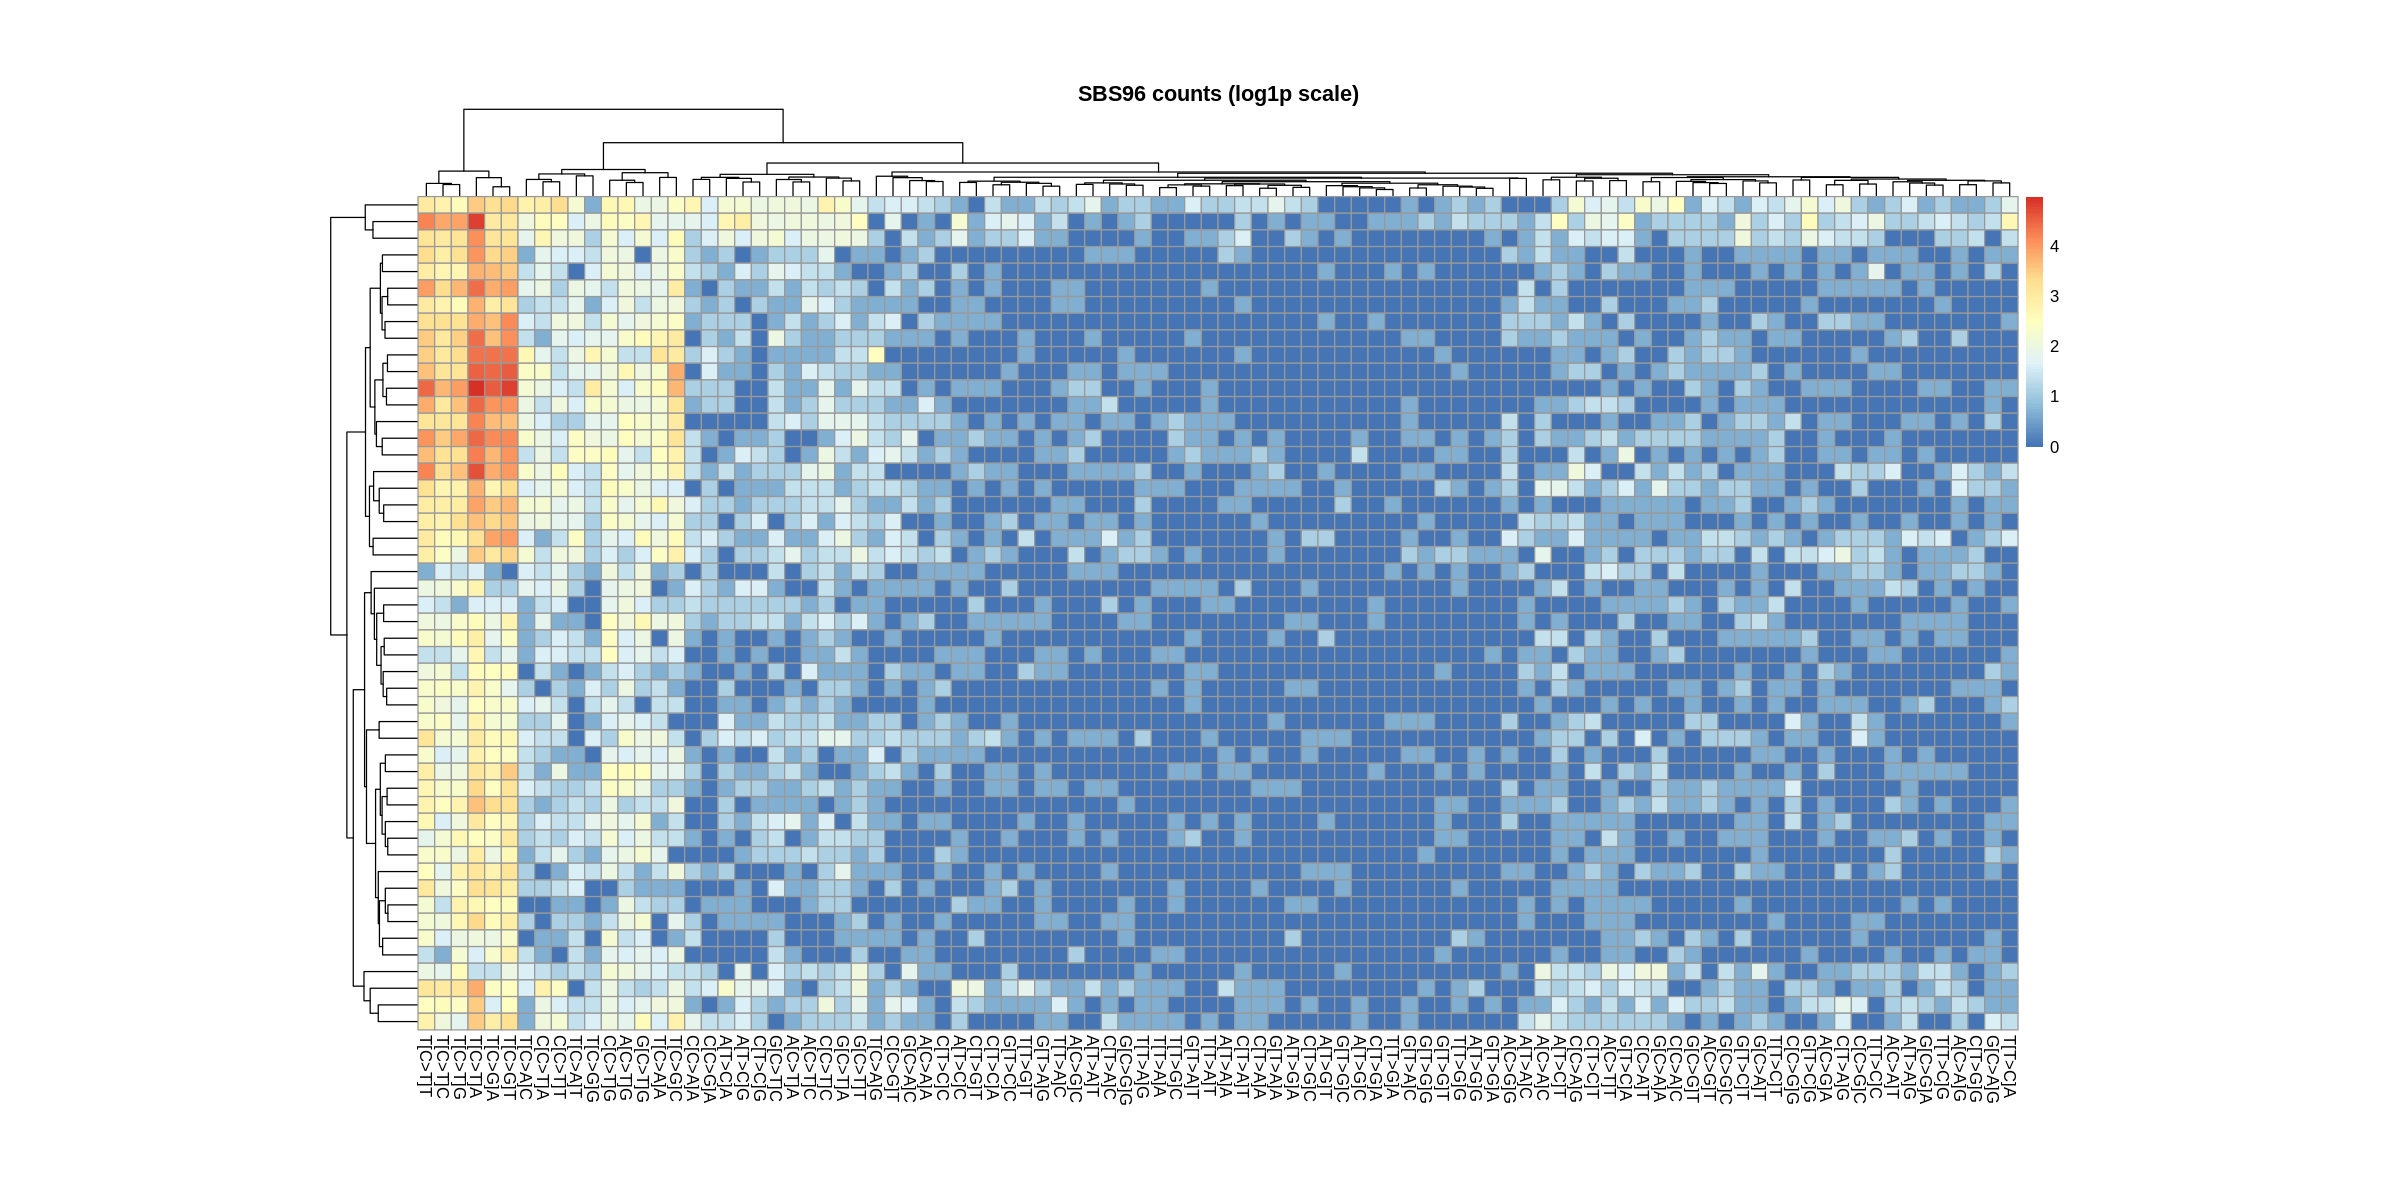

In [45]:
X_log <- log1p(X)  # log(1+count)

options(repr.plot.width=20, repr.plot.height=10)
pheatmap(X_log,
         show_rownames = FALSE,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         cellwidth=10, cellheight=10,
         main = "SBS96 counts (log1p scale)")

# Perform topic modeling via NMF

$K$ is the number of latent signatures.

$H$ contains the signature profiles.

$W$ contains exposures, i.e., how much of each signature contributes in each sample.

In [46]:
set.seed(1)
K <- 8
fit <- nmf(X, rank = K, method = "brunet", nrun = 100) # , .opt = "vp"

# Factor matrices
W <- basis(fit)  # M x K (exposures/activities)
H <- coef(fit)   # K x N (signature profiles)

## Normalize matricies

In [47]:
# Normalize signature profiles to probability distributions
H_norm <- H / rowSums(H)
# # Per-sample exposures in absolute units (mutations attributed per signature)
# sample_totals <- colSums(V)
# Normalize exposures to proportions per sample (rows are samples)
W_prop <- W / rowSums(W)

## Visualize results

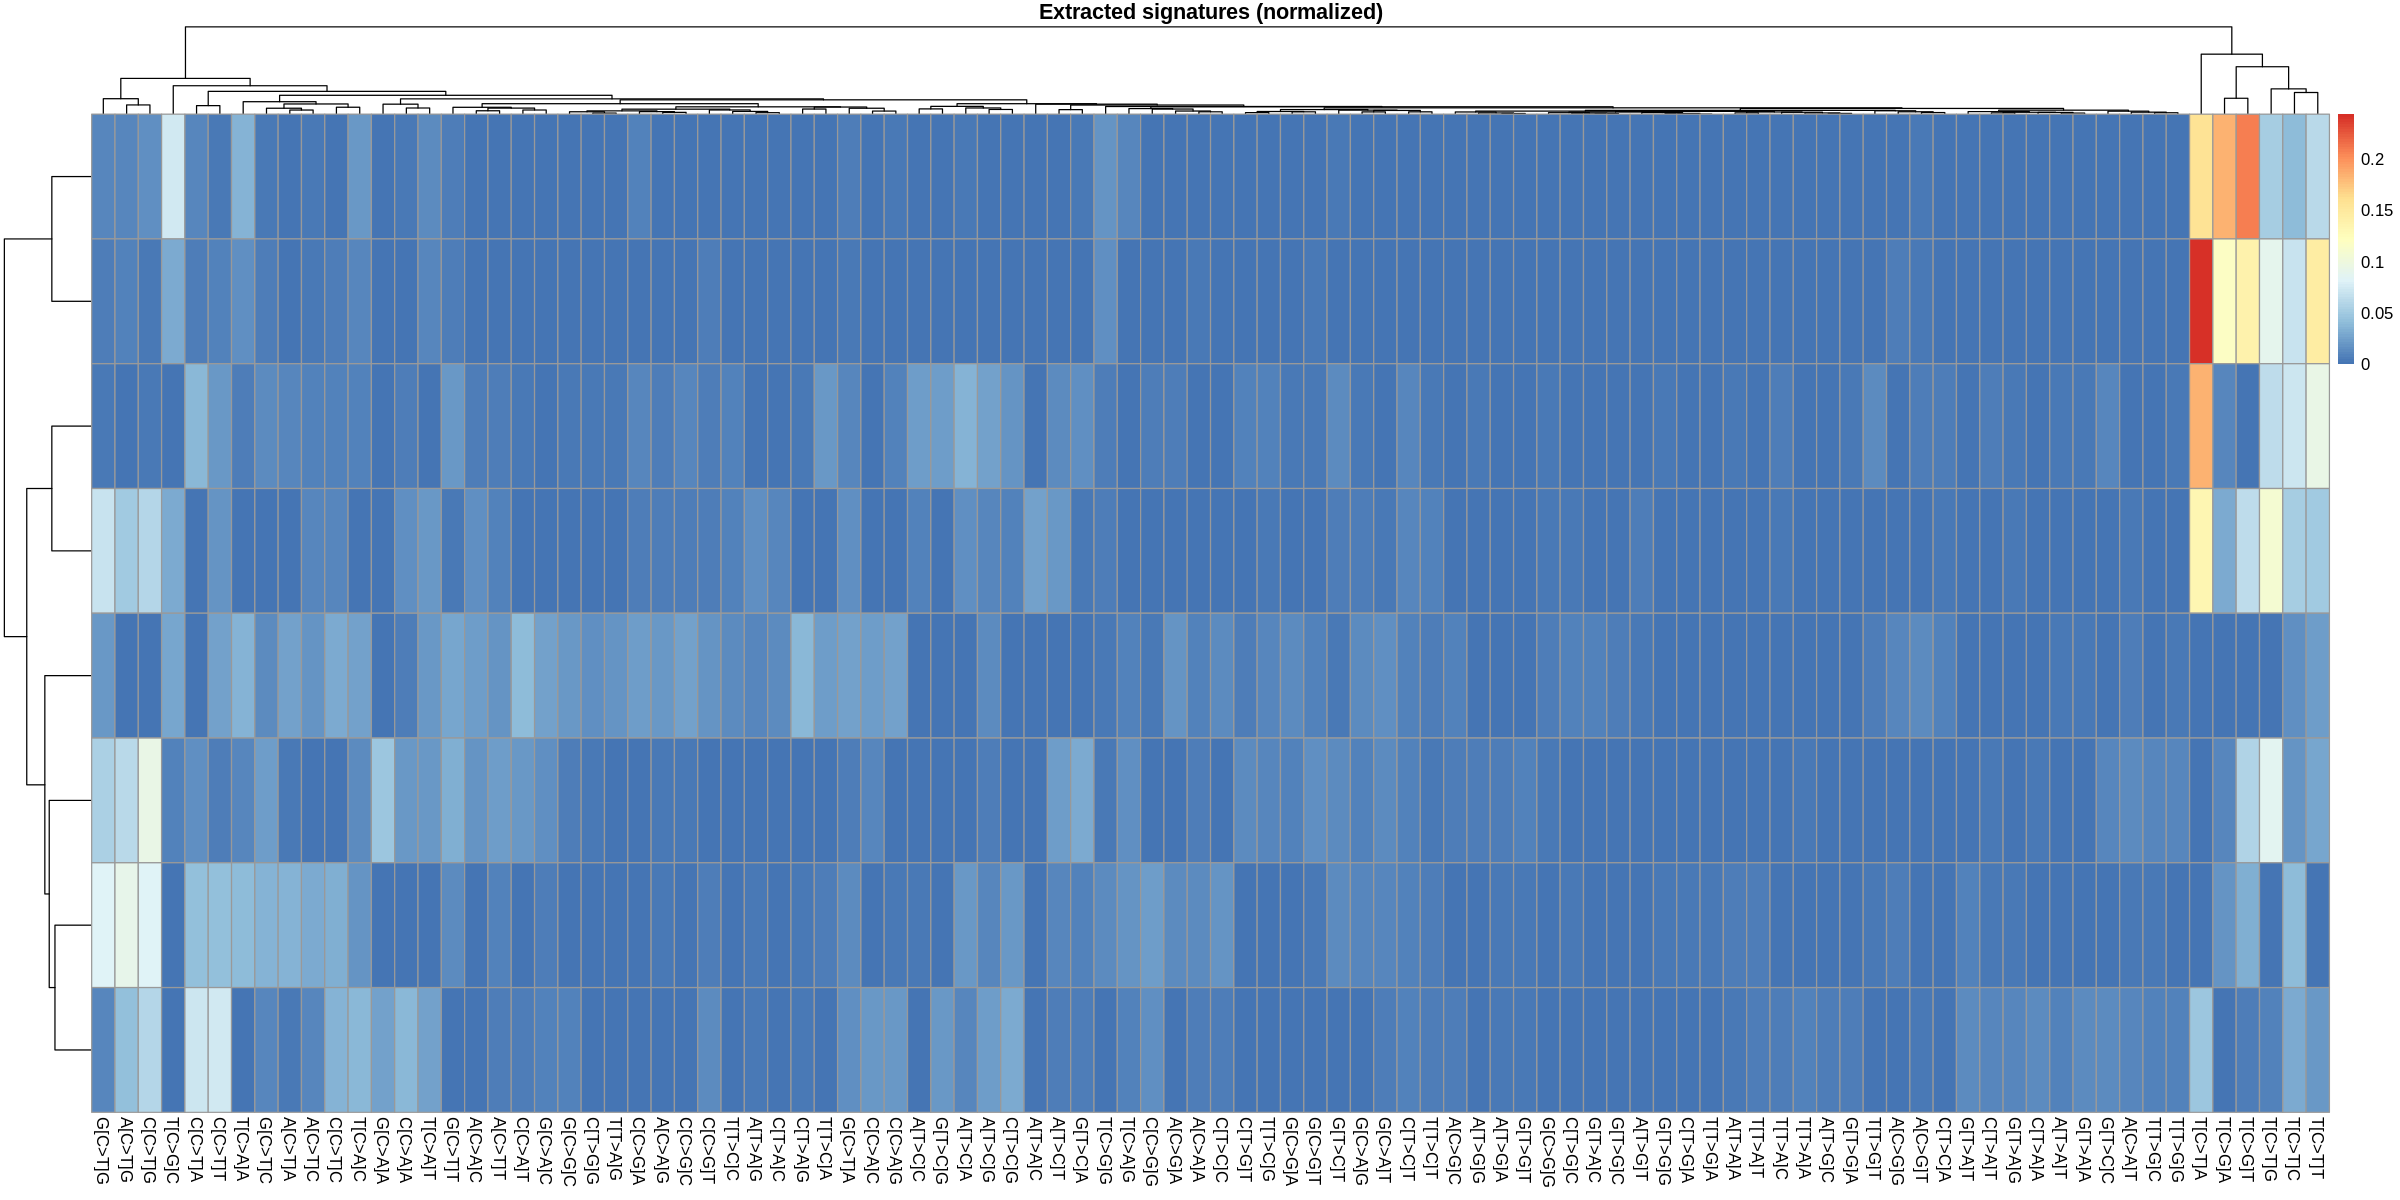

In [48]:
# Heatmap of signatures (K x 96)
pheatmap(H_norm,
         cluster_rows = TRUE, cluster_cols = TRUE,
         show_rownames = FALSE,
         main = "Extracted signatures (normalized)")

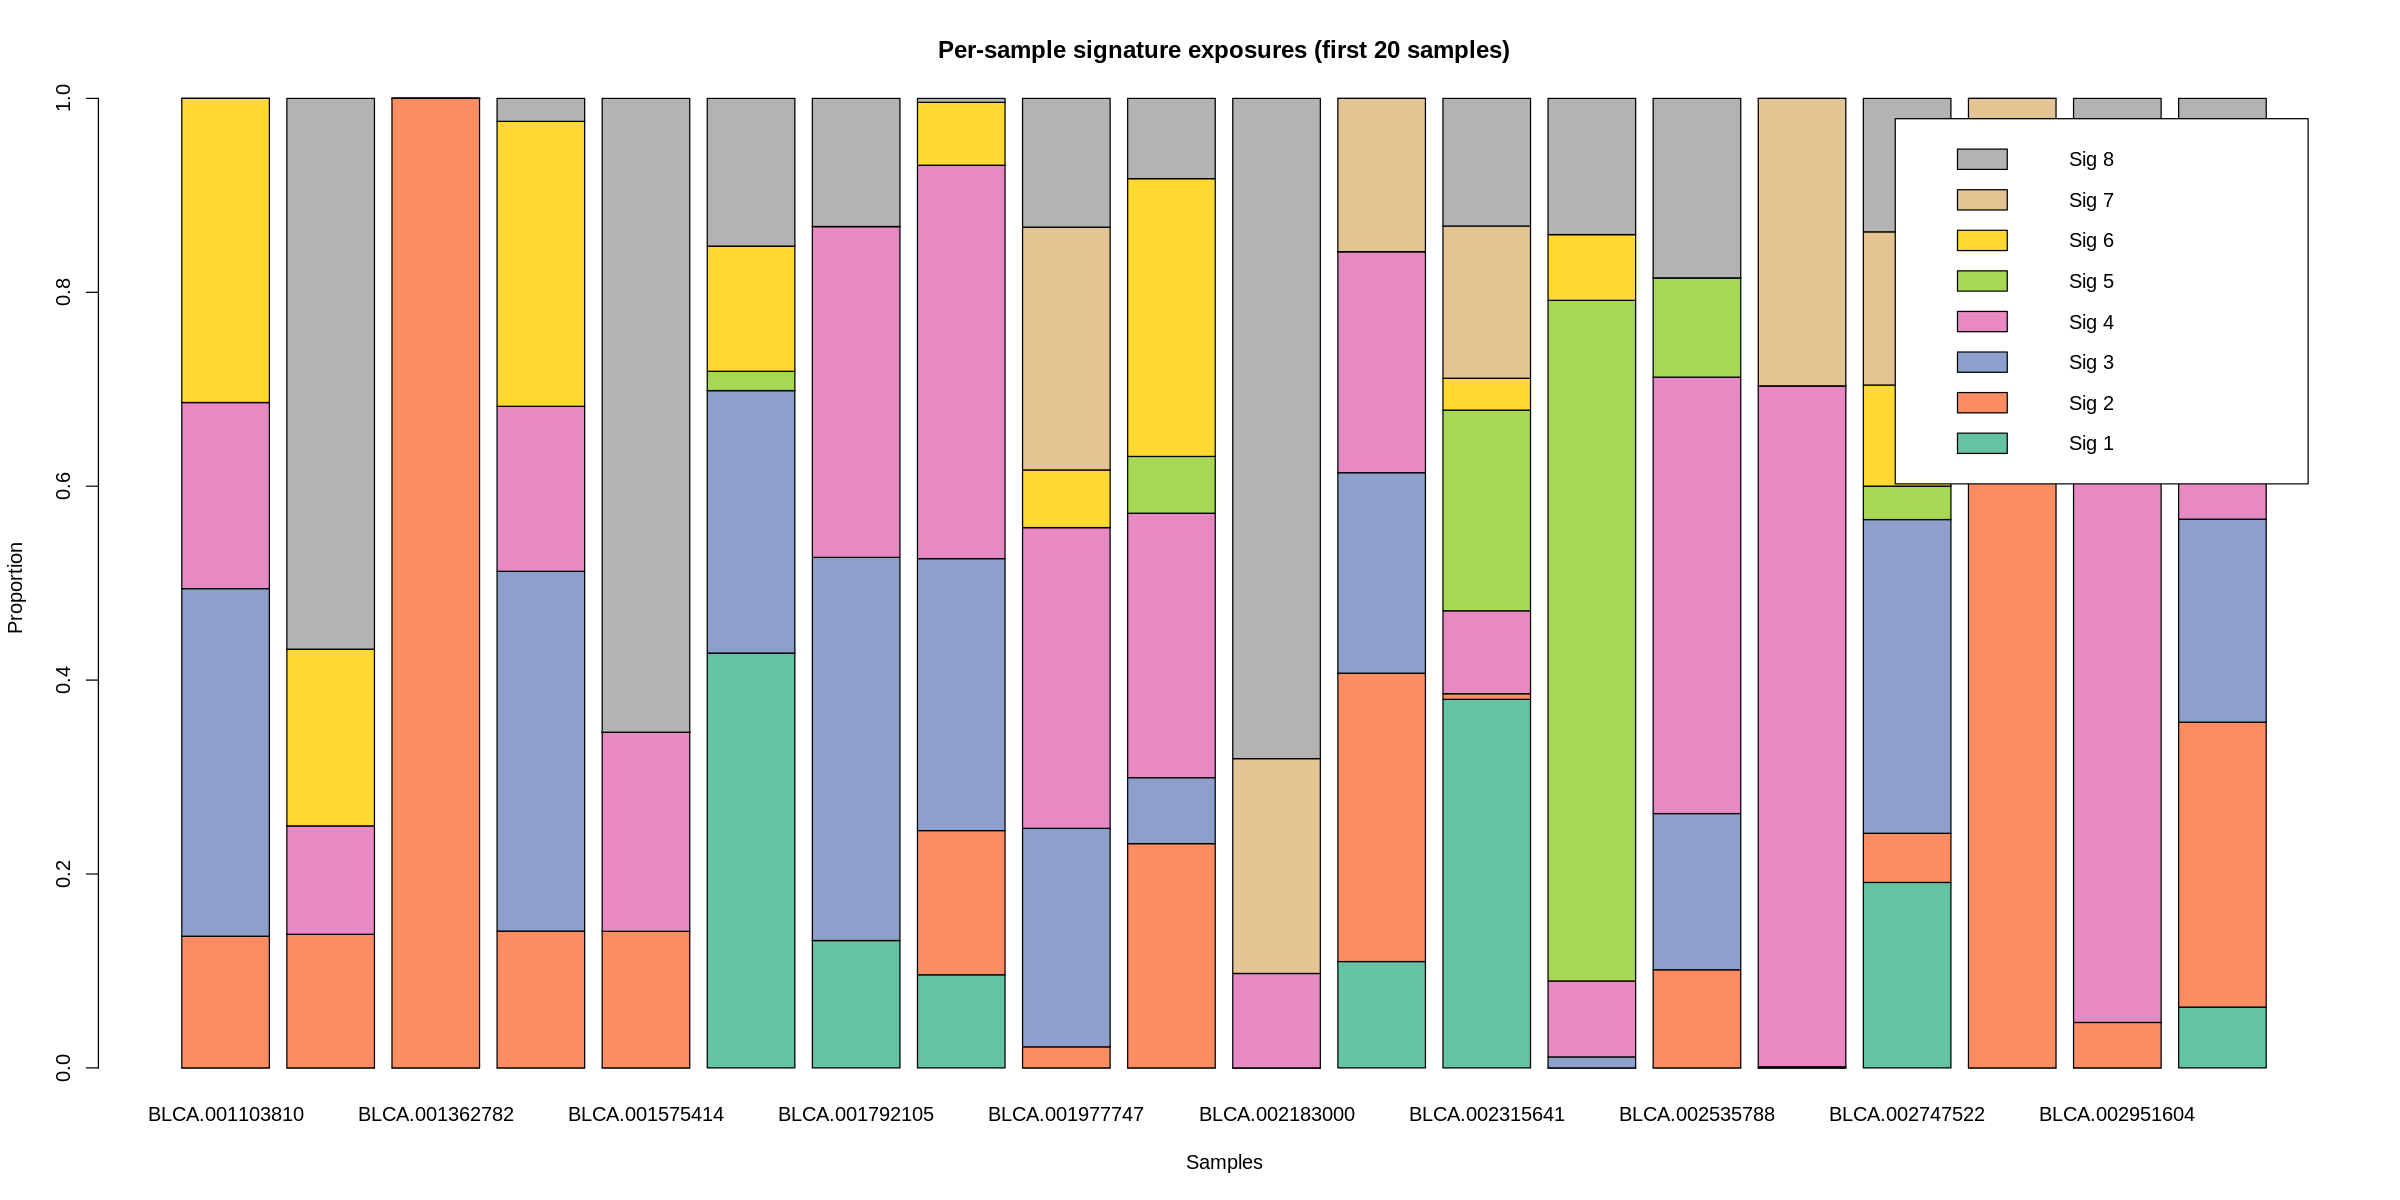

In [51]:
# Exposures: stacked bar per sample (proportions)
cols <- RColorBrewer::brewer.pal(K, "Set2")
barplot(t(W_prop)[, 1:20, drop=FALSE],  # first 20 samples
        col = cols,  # set cmap
        legend = paste("Sig", 1:K),
        xlab = "Samples", ylab = "Proportion",
        main = "Per-sample signature exposures (first 20 samples)")
# par(op)

To label signatures: compare each extracted signature in H_norm to known COSMIC SBS signatures via cosine similarity and assign labels when similarity is high.